# Évaluation des Modèles

In [6]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.evaluation.evaluator import TimeSeriesEvaluator
from src.models.prophet import ProphetRegressor
from src.models.baselines import \
    AverageRegressor, LastWeekPersistenceRegressor, YesterdayPersistenceRegressor, LinearRegressor, SimilarDayRegressor
from src.models.xgboost.xgboost_regressor import XGBoostRegressor

df = pd.read_csv('../data/processed/dataset_final.csv')

In [2]:
evaluator = TimeSeriesEvaluator(df)

val_start = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
test_start = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')

df_train, df_val, df_test = evaluator.split_data(val_start, test_start)

Découpage Temporel
Train: 70127 lignes (74.4%)
Val: 8784 lignes (9.3%)
Test: 15313 lignes (16.3%)



## 3. Modèles de Références

In [ ]:
average_model = AverageRegressor()
evaluator.rolling_validation(average_model, df_train, df_val, freq="1D")

week_model = LastWeekPersistenceRegressor()
evaluator.rolling_validation(week_model, df_train, df_val, freq="1D")

yesterday_model = YesterdayPersistenceRegressor()
evaluator.rolling_validation(yesterday_model, df_train, df_val, freq="1D")

similar_model = SimilarDayRegressor(k=4, temp_weight=0.5)
evaluator.rolling_validation(similar_model, df_train, df_val, freq="1D")

simple_lr_model = LinearRegressor(
	features_cols=[
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
	]
)
evaluator.rolling_validation(simple_lr_model, df_train, df_val, freq="1D")

Évaluation de ProphetRegressor | 8784 lignes | réentraînement/1D | 366 itérations


19:01:02 - cmdstanpy - INFO - Chain [1] start processing
19:01:04 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-01-01 00:00...

19:01:04 - cmdstanpy - INFO - Chain [1] start processing


KeyboardInterrupt: 

In [ ]:
xgb_model = XGBoostRegressor()
evaluator.rolling_validation(xgb_model, df_train, df_val, freq="1D")

In [ ]:
lr_model = LinearRegressor(
	features_cols=[
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
		'temperature_c_pondere_pop_meme_heure_derniere_connue',
		'temperature_c_pondere_pop_derniere_connue',
		'temperature_c_pondere_pop_moins_7', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366'
	]
)
evaluator.rolling_validation(lr_model, df_train, df_val, freq="1D")

prophet_model = ProphetRegressor()
evaluator.rolling_validation(prophet_model, df_train, df_val, freq='1D')

### 4. Visualisation

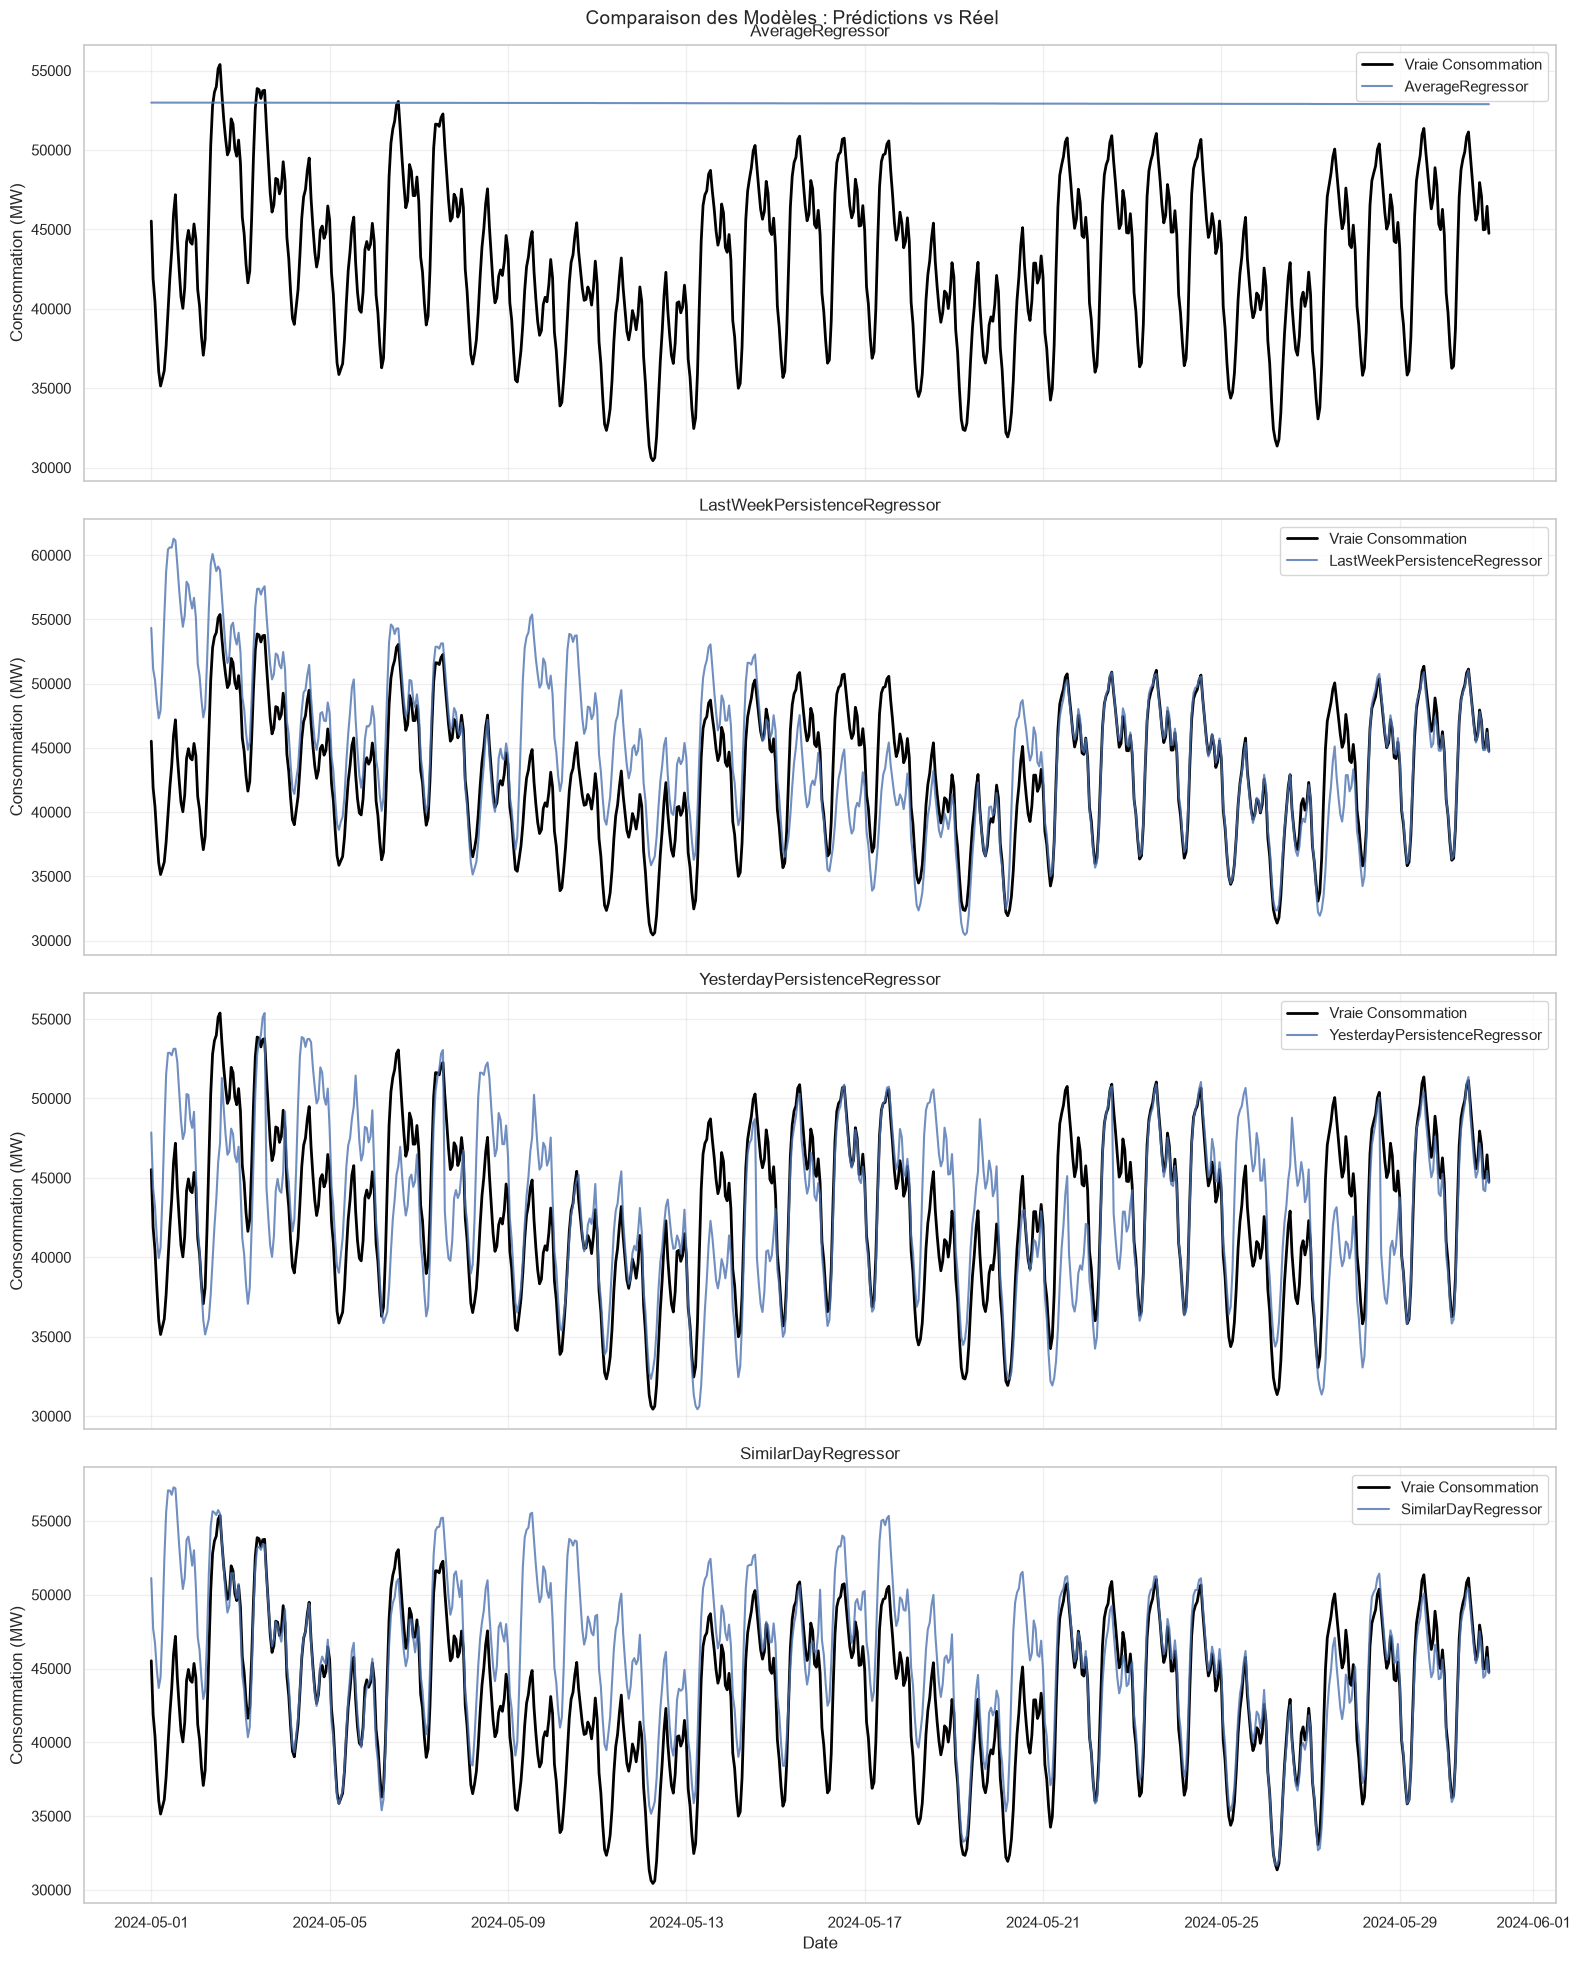

In [ ]:
# Zoomons sur le mois de Mai 2024
start_zoom = pd.to_datetime('2024-05-01').tz_localize('Europe/Paris')
end_zoom = pd.to_datetime('2024-05-31').tz_localize('Europe/Paris')

evaluator.plot_predictions(df_val, start_date=start_zoom, end_date=end_zoom)

## Grid Search Hyperparamètres

In [ ]:
# Recherche des meilleurs paramètres pour le modèle 'Moyenne des jours comparables'
param_grid = {
    'k': [2, 3, 4, 5, 8]  # Teste l'impact de remonter jusqu'à 8 semaines
}

best_params, best_score, results = evaluator.grid_search_rolling_validation(
    SimilarDayRegressor,
    param_grid,
    df_train,
    df_val,
    step_size_days=1,
    metric='MAE'
)

TypeError: TimeSeriesEvaluator.grid_search_rolling_validation() got an unexpected keyword argument 'step_size_days'